##### 코랩을 사용할 경우

In [21]:
try:
    # Google Drive를 Colab(/content/drive)rmfja 에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # Colab에서 작업 디렉토리로 이동
    %cd /google_drive/Othercomputers/'내 컴퓨터'/sec06
    %ls
except ImportError:
    pass

##### 임포트

In [22]:
import torch
from torch.utils.data import Dataset
from sklearn.datasets import load_wine
import numpy as np

##### Device 설정

In [23]:
# Dataset은 기본적으로 CPU에서만 동작
# 사용하지는 않지만, Dataset은 CPU에서 동작한다는 것을 강조하기 위함
device = torch.device('cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


##### Dataset 클래스 작성

In [24]:
class WineDataset(Dataset):
    def __init__(self, transform=None):
        """[필수] 데이터셋 초기화: 데이터 로드, 저장"""
        wine = load_wine()
        # 원본 데이터 그대로 저장 → 표준화는 transform에게 위임
        self.features = wine.data.astype(np.float32)   # (178, 13)
        self.labels   = wine.target.astype(np.int64)   # (178,)
        # transform은 샘플 반환 직전에 적용할 전처리 객체
        self.transform = transform

    def __len__(self):
        """[필수] 전체 샘플 수 반환: len(dataset) 호출 시 실행되는 메소드"""
        return len(self.features)

    def __getitem__(self, idx):
        """[필수] 인덱스 idx에 해당하는 샘플 반환: dataset[idx] 호출 시 실행되는 메소드"""
        x = torch.tensor(self.features[idx])   # float32 → torch.float32
        y = torch.tensor(self.labels[idx])     # int64   → torch.long

        if self.transform:
            x = self.transform(x)              # 샘플 반환 직전에 transform 실행

        return x, y

##### Transform 함수 정의

In [25]:
# 테이블 데이터 전처리용 Transform: 피처를 평균=0, 표준편차=1로 표준화"""
def standard_scale_transform(x: torch.Tensor) -> torch.Tensor:
    # 샘플 x의 피처별 평균·표준편차를 직접 계산
    mean = x.mean()
    std  = x.std()
    # (x - 평균) / 표준편차
    # 1e-8: std가 0인 경우(값이 모두 동일) 0 나눗셈 방지
    return (x - mean) / (std + 1e-8)

In [26]:
# 참고: PIL 이미지 데이터셋 전처리를 위해 여러가시 Transform으로 파이프라인을 구성한 예
# from torchvision import transforms
# transform = transforms.Compose([
#     # 크기 조정
#     transforms.Resize((224, 224)),
#     # PIL (H, W, C) → [0,1.0] 범위의 (C, H, W) 텐서로 변환
#     transforms.ToTensor(),
#     # (C, H, W)일 경우 채널별 표준화
#     transforms.Normalize(           
#         mean=(0.485, 0.456, 0.406),  # 채널별 평균
#         std =(0.229, 0.224, 0.225)   # 채널별 표준편차
#     ),
#     # 기타 사용자 정의 함수, 람다, 객체 타입도 추가 가능
# ])

##### WineDataset 생성

In [27]:
dataset   = WineDataset(transform=standard_scale_transform)

사용 장치: cpu
전체 샘플 수 : 178
학습 샘플 수 : 142
검증 샘플 수 : 18
테스트 샘플 수: 18
학습셋:  [0, 1, 2] [33.098591549295776, 40.140845070422536, 26.76056338028169]
검증셋:  [0, 1, 2] [33.33333333333333, 38.88888888888889, 27.77777777777778]
테스트셋:  [0, 1, 2] [33.33333333333333, 38.88888888888889, 27.77777777777778]


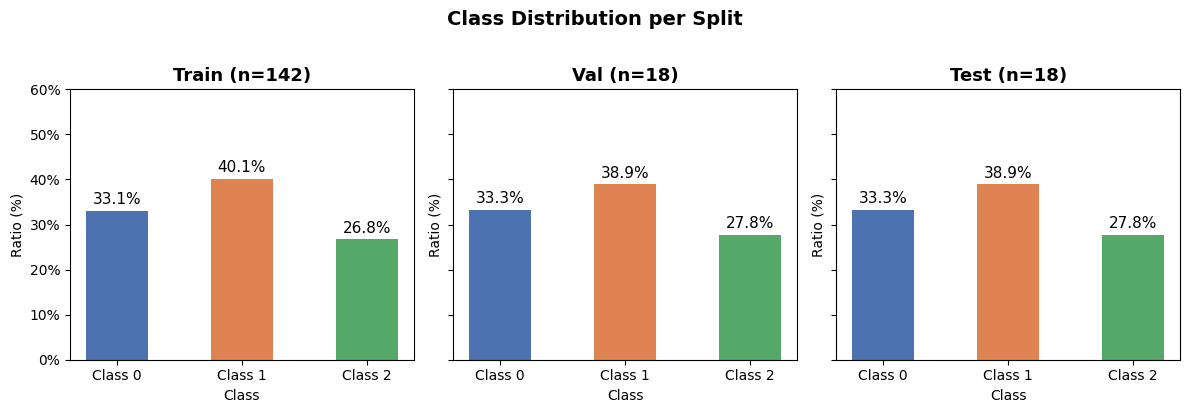

In [28]:
%run "02_dataset_split.ipynb"


In [29]:
%run "03_dataloader.ipynb"

사용 장치: cpu
전체 샘플 수 : 178
학습 샘플 수 : 142, 검증 샘플 수:  18, 테스트 샘플 수:  18
학습 배치 수 :   8, 검증 배치 수:   2, 테스트 배치 수:   2


In [30]:
%run "04_training.ipynb"

사용 장치: cpu
✓ 모델 생성 완료
WineClassifier(
  (model): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)
Epoch [  1/100]  훈련 손실: 1.0610  훈련 정확도:  43.7%  검증 손실: 1.0109  검증 정확도:  72.2%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  2/100]  훈련 손실: 0.9910  훈련 정확도:  64.1%  검증 손실: 0.9139  검증 정확도:  94.4%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  3/100]  훈련 손실: 0.9047  훈련 정확도:  71.1%  검증 손실: 0.8061  검증 정확도: 100.0%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  4/100]  훈련 손실: 0.8088  훈련 정확도:  74.6%  검증 손실: 0.6910  검증 정확도: 100.0%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  5/100]  훈련 손실: 0.6990  훈련 정확도:  83.1%  검증 손실: 0.5721  검증 정확도: 100.0%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  6/100]  훈련 손실: 0.6046  훈련 정확도:  81.0%  검증 손실: 0.4548  검증 정확도: 100.0%  lr: 0.001000  ✓ 최적 모델 저장
Epoch [  7/100]  훈련 